## 1. Data Preparation


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter
from scipy.integrate import trapezoid
import seaborn as sns
import matplotlib.patches as mpatches
import pickle
from tqdm.auto import tqdm

from utils_load_data import *
from utils_trajectories import *

# ---- Paths ----
save_directory = "./"

# ---- Parameters ----
dt = 0.005
t_pre, t_post = 0.3, 0.3  # PSTH window around each event
time = np.arange(-t_pre, t_post + dt, dt)
spike_sorted = True

# ---- Plotting style ----
mpl.rcdefaults()
plt.rcParams.update({
    'font.size':        7,
    'axes.linewidth':   0.5,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'xtick.major.width':0.5,
    'ytick.major.width':0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.direction':  'out',
    'ytick.direction':  'out',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

print("Imports and config ready.")

In [ ]:
# ---- Load data ----
# MP1 = playback sessions, MP2 = mapping_change_only sessions

files = ['SKIEUR_hs_0']

def load_dataset(session_type, spike_sorted, dt):
    """Load pre-pickled neural + feature data for a given session type."""
    n_data_all, f_data_all = [], []
    suffix = "_ss" if spike_sorted else ""
    for file in files:
        path = rf"\\129.199.81.18\data5\eTheremin\{file}_{session_type}_{dt}_data{suffix}"
        with open(path, "rb") as fp:
            n_data_all.append(pickle.load(fp))
        path_feat = rf"\\129.199.81.18\data5\eTheremin\{file}_{session_type}_{dt}_feature{suffix}"
        with open(path_feat, "rb") as fp:
            f_data_all.append(pickle.load(fp))
    return n_data_all, f_data_all

n_data_all_mp2, f_data_all_mp2 = load_dataset('mapping_change_only', spike_sorted, dt)
n_data_all_mp1, f_data_all_mp1 = load_dataset('playback', spike_sorted, dt)

print(f"MP1 (playback): {len(n_data_all_mp1[0])} sessions loaded")
print(f"MP2 (mapping_change_only): {len(n_data_all_mp2[0])} sessions loaded")

In [ ]:
# ---- Preprocess -> Split -> Extract trajectories -> build_traj ----
# n_data_all_mp1 is [list_of_session_arrays] — take [0] for the single-file case
n_pre = int(t_pre/dt - 1)

# Toggle: force equal session count between MP1 and MP2
FORCE_EQUAL = 1
n_mp1 = len(n_data_all_mp1[0])
n_mp2 = len(n_data_all_mp2[0])
n_use_mp1 = n_mp1
n_use_mp2 = n_mp2
if FORCE_EQUAL:
    n_min = min(n_mp1, n_mp2)
    n_use_mp1 = n_min
    n_use_mp2 = n_min
    print(f"FORCE_EQUAL=1  MP1={n_mp1} -> {n_min}, MP2={n_mp2} -> {n_min}")
else:
    print(f"FORCE_EQUAL=0  MP1={n_mp1}, MP2={n_mp2} (all sessions)")

data_pairs = [
    ('MP1', (n_data_all_mp1[0][:n_use_mp1], f_data_all_mp1[0][:n_use_mp1])),
    ('MP2', (n_data_all_mp2[0][:n_use_mp2], f_data_all_mp2[0][:n_use_mp2])),
]
for mp_label, (n_data_list, f_data_list) in data_pairs:
    # preprocess: smooth + baseline-remove + reorganise + filter
    n_data_list = remove_average(smooth_data(n_data_list))
    n_before_reorg = len(n_data_list)
    n_data_list, f_data_list = re_organise_data([n_data_list], [f_data_list])
    n_after_reorg = len(n_data_list)
    if n_after_reorg != n_before_reorg:
        print(f"  {mp_label}: re_organise_data reshaped {n_before_reorg} -> {n_after_reorg} sessions")

    n_before_filter = len(n_data_list)
    n_data_list, f_data_list = zip(*[(n, f) for n, f in zip(n_data_list, f_data_list)
                                      if abs(n.shape[-1] - len(f)) <= 2])
    n_data_list, f_data_list = list(n_data_list), list(f_data_list)
    n_dropped = n_before_filter - len(n_data_list)
    if n_dropped > 0:
        print(f"  {mp_label}: shape-filter dropped {n_dropped} of {n_before_filter} sessions "
              f"(kept {len(n_data_list)})")

    n_half = len(n_data_list) // 2
    beg_n, exp_n = list(n_data_list[:n_half]), list(n_data_list[n_half:2*n_half])
    beg_f, exp_f = list(f_data_list[:n_half]), list(f_data_list[n_half:2*n_half])

    # extract H1/H2 trajectories per expertise level
    groups = {'beg': (beg_n, beg_f), 'exp': (exp_n, exp_f)}
    results = {}
    for grp_name, (nd, fd) in groups.items():
        results[grp_name] = {}
        for start, end in [(0.0, 0.5), (0.5, 1.0)]:
            results[grp_name][(start, end)] = extract_traj_subset(
                nd, fd, t_pre, t_post, dt,
                overlap_thresh=1.0, n_pre=n_pre, full=True,
                trial_start=start, trial_end=end)

    # build_traj: reorganise into half_key -> {track/pb} -> {beg/exp}
    traj = {}
    for q in [(0.0, 0.5), (0.5, 1.0)]:
        tb, pb, *_ = results['beg'][q]
        te, pe, *_ = results['exp'][q]
        traj[q] = {'track': {'beg': tb, 'exp': te},
                   'pb':    {'beg': pb, 'exp': pe}}

    if mp_label == 'MP1':
        traj_by_half_mp1 = traj
    else:
        traj_by_half_mp2 = traj

    print(f"{mp_label}: {n_half*2} sessions")

print("Ready for LMM.")
print()
# Read Google Sheet to map pickle index -> session name
import pandas as pd
sheet_url = "https://docs.google.com/spreadsheets/d/1sFatSTXO0j3OONKstz7YN-mM04kNMjk_r7zo951yicU/gviz/tq?tqx=out:csv&sheet=SKIEUR"
df_sheet = pd.read_csv(sheet_url)
df_sheet = df_sheet[df_sheet["use"] == "yes"]
print("Beginner/Expert split (by pickle order, chronological):")
for mp_label, n_data_list, stype in [
    ("MP1 (playback)", n_data_all_mp1[0], "playback"),
    ("MP2 (mapping)", n_data_all_mp2[0], "mapping_change_only"),
]:
    n_sess = len(n_data_list)
    n_half = n_sess // 2
    # Get session names from Google Sheet for this type (matches pickle order)
    sessions = df_sheet[df_sheet["type"] == stype]["session"].tolist()
    # Trim to actual loaded count (re_organise_data may filter some)
    sessions = sessions[:n_sess]
    print(f"  {mp_label}: {n_sess} sessions (n_half={n_half})")
    print(f"    Beginner:")
    for i, s in enumerate(sessions[:n_half]):
        print(f"      idx={i:3d}  {s}")
    print(f"    Expert:")
    for i, s in enumerate(sessions[n_half:]):
        print(f"      idx={i + n_half:3d}  {s}")
    print()

In [ ]:
# # Load session list from Google Sheet and show Beginner/Expert split
# import pandas as pd

# SHEET_ID = '1sFatSTXO0j3OONKstz7YN-mM04kNMjk_r7zo951yicU'
# SHEET_NAME = 'SKIEUR'
# url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet={SHEET_NAME}'
# df = pd.read_csv(url)
# df = df[df['use'] == 'yes']
# print(f'Total sessions marked use=yes in Google Sheet: {len(df)}')
# print(f'Session types: {sorted(df["type"].unique())}')
# print()

# # For each session type, show the session names in order (this matches pickle order)
# # Beginner = first half, Expert = second half
# for stype in sorted(df['type'].unique()):
#     subset = df[df['type'] == stype]
#     sessions = subset['session'].tolist()
#     n = len(sessions)
#     n_half = n // 2
#     print('=' * 70)
#     print(f'  Session type: {stype}  ({n} sessions)')
#     print('=' * 70)
#     print(f'  BEGINNER (first {n_half}):')
#     for i, s in enumerate(sessions[:n_half]):
#         print(f'    pickle_idx={i:3d}  {s}')
#     print(f'  EXPERT (last {n - n_half}):')
#     for i, s in enumerate(sessions[n_half:]):
#         print(f'    pickle_idx={i + n_half:3d}  {s}')
#     print()

## 2. Group-Level Tests


### 2.1 Quick ANOVA: Track vs PB, MP1 vs MP2


In [ ]:
# ===============================================================
# Quick tests: Track vs PB, MP1 vs MP2  (mean + peak amplitude)
# ===============================================================
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import build_lmm_dataframe
from scipy.stats import ttest_rel, ttest_ind


# For global FDR correction
all_p_vals_anova = []
all_p_labels_anova = []

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms")]:
        sep = "=" * 60
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)

        df1 = build_lmm_dataframe(traj_by_half_mp1, "MP1", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df2 = build_lmm_dataframe(traj_by_half_mp2, "MP2", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df = pd.concat([df1, df2], ignore_index=True)

        # ---- 1. Track vs Playback (paired per neuron) ----
        tr = df[df["condition"] == "Track"]["response"].values
        pb = df[df["condition"] == "Playback"]["response"].values
        t_tr_pb, p_tr_pb = ttest_rel(pb, tr)
        print("  Track vs Playback (paired t-test):")
        print("    Track {:.4f}, PB {:.4f}, diff={:.4f}".format(tr.mean(), pb.mean(), pb.mean() - tr.mean()))
        print("    t={:.3f}, p={:.4e}".format(t_tr_pb, p_tr_pb))
        all_p_vals_anova.append(p_tr_pb)
        all_p_labels_anova.append("Track-vs-PB_" + metric + "_" + label)

        # ---- 2. MP1 vs MP2 (Welch, per-neuron mean) ----
        df_neuron = df.groupby(["neuron_id", "mapping"])["response"].mean().reset_index()
        mp1_vals = df_neuron[df_neuron["mapping"] == "MP1"]["response"].values
        mp2_vals = df_neuron[df_neuron["mapping"] == "MP2"]["response"].values
        t_mp, p_mp = ttest_ind(mp1_vals, mp2_vals, equal_var=False)
        print()
        print("  MP1 vs MP2 (Welch t-test):")
        print("    MP1 {:.4f}, MP2 {:.4f}, diff={:.4f}".format(np.mean(mp1_vals), np.mean(mp2_vals), np.mean(mp2_vals) - np.mean(mp1_vals)))
        print("    t={:.3f}, p={:.4e}".format(t_mp, p_mp))
        all_p_vals_anova.append(p_mp)
        all_p_labels_anova.append("MP1-vs-MP2_" + metric + "_" + label)
        print()

# ── Global FDR correction (across all metrics & windows) ──
from statsmodels.stats.multitest import multipletests
if all_p_vals_anova:
    reject, p_fdr, _, _ = multipletests(all_p_vals_anova, method='fdr_bh')
    print()
    print("=" * 70)
    print("  QUICK TESTS: GLOBAL FDR CORRECTION (Benjamini-Hochberg)")
    print("=" * 70)
    print(f"  {'Test':<40s} {'p_raw':>10s} {'p_fdr':>10s}  {'Sig.'}")
    print(f"  {'-'*64}")
    for label, p_raw, p_corr in zip(all_p_labels_anova, all_p_vals_anova, p_fdr):
        sig = '***' if p_corr<0.001 else ('**' if p_corr<0.01 else ('*' if p_corr<0.05 else 'n.s.'))
        print(f"  {label:<40s} {p_raw:10.6f} {p_corr:10.6f}  {sig}")


### 2.2 LMM: `condition * expertise * half`


In [ ]:
# ===============================================================
# LMM: condition * expertise * half  (no mapping)
# Random: (1 | neuron_id) + (1 | session_id)
# ===============================================================
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import build_lmm_dataframe
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2

formula_no_mapping = 'response ~ condition * expertise * half'


# For global FDR correction
all_p_vals_lmm1 = []
all_p_labels_lmm1 = []

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms")]:
        sep = "=" * 60
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)

        df1 = build_lmm_dataframe(traj_by_half_mp1, "MP1", time,
                                   auc_t_start=0.0, auc_t_end=t_window, metric=metric)
        df2 = build_lmm_dataframe(traj_by_half_mp2, "MP2", time,
                                   auc_t_start=0.0, auc_t_end=t_window, metric=metric)
        df_all = pd.concat([df1, df2], ignore_index=True)
        n_n = df_all["neuron_id"].nunique()
        n_s = df_all["session_id"].nunique()
        print("{} neurons, {} sessions, {} rows".format(n_n, n_s, len(df_all)))

        vc = {"session_id": "0 + C(session_id)"}
        m = smf.mixedlm(formula_no_mapping, df_all, groups=df_all["neuron_id"], vc_formula=vc)
        r = m.fit(reml=True)
        print(r.summary())

        print()
        print("  All coefficients (p-value):")
        for name, p in r.pvalues.items():
            stars = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else ""))
            print("    {}: p={:.4e} {}".format(name, p, stars))
            all_p_vals_lmm1.append(p)
            all_p_labels_lmm1.append(metric + "_" + label + "_" + name)

# ── Global FDR correction ──
from statsmodels.stats.multitest import multipletests
if all_p_vals_lmm1:
    reject, p_fdr, _, _ = multipletests(all_p_vals_lmm1, method='fdr_bh')
    print()
    print("=" * 70)
    print("  LMM (no mapping): GLOBAL FDR CORRECTION (BH)")
    print("=" * 70)
    n_sig = sum(reject)
    print(f"  {n_sig}/{len(p_fdr)} tests significant after FDR")
    for label, p_raw, p_corr, rej in zip(all_p_labels_lmm1, all_p_vals_lmm1, p_fdr, reject):
        if p_corr < 0.05:
            sig = '***' if p_corr<0.001 else ('**' if p_corr<0.01 else '*')
            print(f"  {label:<55s} raw={p_raw:.2e}  fdr={p_corr:.2e}  {sig}")


### 2.3 LMM: `condition * mapping * expertise` + `(1|session_id)`


In [ ]:
# ===============================================================
# LMM: condition * mapping * expertise  (no half)
# Random: (1 | neuron_id) + (1 | session_id)
# ===============================================================
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import build_lmm_dataframe
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2

formula_no_half = 'response ~ condition * mapping * expertise'


# For global FDR correction
all_p_vals_lmm2 = []
all_p_labels_lmm2 = []

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms")]:
        sep = "=" * 60
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)

        df1 = build_lmm_dataframe(traj_by_half_mp1, "MP1", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df2 = build_lmm_dataframe(traj_by_half_mp2, "MP2", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df_all = pd.concat([df1, df2], ignore_index=True)
        n_n = df_all["neuron_id"].nunique()
        n_s = df_all["session_id"].nunique()
        print("{} neurons, {} sessions, {} rows".format(n_n, n_s, len(df_all)))

        # Model A: Fixed only
        m0 = smf.mixedlm(formula_no_half, df_all, groups=df_all["neuron_id"])
        r0 = m0.fit(reml=False)

        # Model B: + (1 | neuron_id)
        m1 = smf.mixedlm(formula_no_half, df_all, groups=df_all["neuron_id"])
        r1 = m1.fit(reml=True)

        # Model C: + (1 | neuron_id) + (1 | session_id)  [CORRECT]
        vc = {"session_id": "0 + C(session_id)"}
        m2 = smf.mixedlm(formula_no_half, df_all, groups=df_all["neuron_id"], vc_formula=vc)
        r2 = m2.fit(reml=True)

        print()
        print("  COMPARISON: p-values by model")
        print("  Effect                              Model A (fixed)  Model B (+neuron)  Model C (+session)")
        print("  " + "-" * 88)
        for name in r2.fe_params.index:
            p_a = r0.pvalues.get(name, float("nan"))
            p_b = r1.pvalues.get(name, float("nan"))
            p_c = r2.pvalues.get(name, float("nan"))
            is_between = any(kw in name.lower() for kw in ["mapping", "expertise"])
            flag = " <-- pseudo-rep?" if is_between else ""
            print("  {:<35s}  {:<14.2e}  {:<14.2e}  {:<14.2e}{}".format(name[:35], p_a, p_b, p_c, flag))

        aic = [r0.aic, r1.aic, r2.aic]
        print()
        print("  AIC: fixed={:.1f}, +neuron={:.1f}, +session={:.1f}".format(aic[0], aic[1], aic[2]))

        # Collect key p-values for FDR
        for name in r2.fe_params.index:
            p = r2.pvalues[name]
            all_p_vals_lmm2.append(p)
            all_p_labels_lmm2.append(metric + "_" + label + "_" + name)

# ── Global FDR correction ──
from statsmodels.stats.multitest import multipletests
if all_p_vals_lmm2:
    reject, p_fdr, _, _ = multipletests(all_p_vals_lmm2, method='fdr_bh')
    print()
    print("=" * 70)
    print("  LMM (no half): GLOBAL FDR CORRECTION (BH)")
    print("=" * 70)
    n_sig = sum(reject)
    print(f"  {n_sig}/{len(p_fdr)} tests significant after FDR")
    for label, p_raw, p_corr, rej in zip(all_p_labels_lmm2, all_p_vals_lmm2, p_fdr, reject):
        if p_corr < 0.05:
            sig = '***' if p_corr<0.001 else ('**' if p_corr<0.01 else '*')
            print(f"  {label:<55s} raw={p_raw:.2e}  fdr={p_corr:.2e}  {sig}")


### 2.4 Full LMM: `condition * mapping * expertise * half`


In [ ]:
#%matplotlib qt

In [ ]:
# LMM: Track vs Playback, MP1 vs MP2
#
# Response: mean or peak amplitude (baseline-subtracted) in post-trigger window
# Fixed:    condition (Track/PB) x mapping (MP1/MP2) x expertise x half
# Random:   (1 + condition | neuron_id)

import sys
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import run_lmm_analysis, compare_random_effect_structures


# For global FDR correction (collects LRT/Wald p-values from run_lmm_analysis)
all_p_vals_full = []
all_p_labels_full = []

def _collect_lmm_pvals(result, df_lmm, prefix):
    """Capture the key p-values from run_lmm_analysis output."""
    # Collect key coefficient p-values
    for name in result.fe_params.index:
        if 'condition' in name.lower() or 'mapping' in name.lower():
            all_p_vals_full.append(result.pvalues[name])
            all_p_labels_full.append(prefix + "_" + name)

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms")]:
        sep = "=" * 70
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)
        result_lmm, df_lmm = run_lmm_analysis(
            traj_by_half_mp1, traj_by_half_mp2, time, save_directory,
            auc_t_start=0.0, auc_t_end=t_window, metric=metric
        )
        compare_random_effect_structures(df_lmm)
        _collect_lmm_pvals(result_lmm, df_lmm, metric + "_" + label)

# ── Global FDR correction ──
from statsmodels.stats.multitest import multipletests
if all_p_vals_full:
    reject, p_fdr, _, _ = multipletests(all_p_vals_full, method='fdr_bh')
    print()
    print("=" * 70)
    print("  FULL LMM: GLOBAL FDR CORRECTION (Benjamini-Hochberg)")
    print("=" * 70)
    n_sig = sum(reject)
    print(f"  {n_sig}/{len(p_fdr)} condition/mapping coefficients significant after FDR")
    for label, p_raw, p_corr, rej in zip(all_p_labels_full, all_p_vals_full, p_fdr, reject):
        if p_corr < 0.05:
            sig = '***' if p_corr<0.001 else ('**' if p_corr<0.01 else '*')
            print(f"  {label:<55s} raw={p_raw:.2e}  fdr={p_corr:.2e}  {sig}")


### 2.5 Peak Analysis: 0-200ms (Full LMM)

Peak response in 0–200ms post-trigger window. The peak (maximum) captures the strongest transient, which for sensory/motor cortex typically occurs 50–150ms post-stimulus. The 200ms cutoff excludes late sustained activity.

Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1028 (514 neurons x 2 conditions)
  Unique sessions: 28
    MP1: 14 sessions, 194 neurons
    MP2: 14 sessions, 320 neurons

-- Data Summary (mean response +/- SEM) --
                                     mean      std  count      sem
mapping condition expertise half                                  
MP1     Playback  Beginner  H1    0.01618  0.00967     13  0.00268
                            H2    0.01371  0.00804     13  0.00223
                  Expert    H1    0.01667  0.03118     84  0.00340
                            H2    0.01292  0.02107     84  0.00230
        Track     Beginner  H1    0.01685  0.01258     13  0.00349
                            H2    0.01415  0.00923     13  0.00256
                  Expert    H1    0.01761  0.02963     84  0.00323
                            H2    0.01356  0.02199     84  0.00240
MP2     Playback  Beginner  H1    0.01557  0.02320     75  0.00268
            

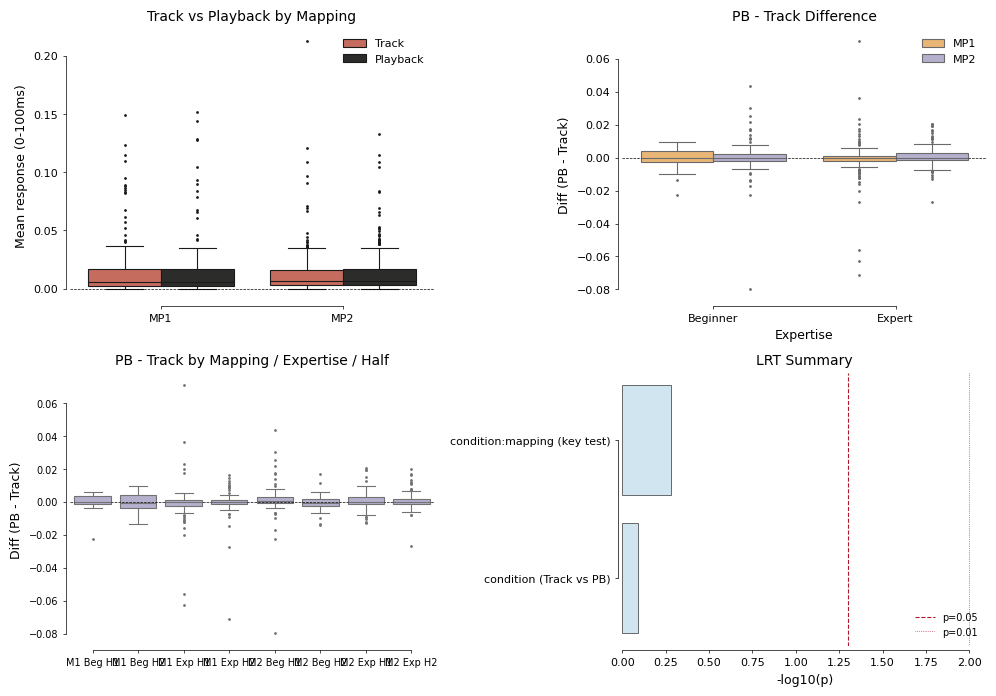


  Tip: run '%matplotlib qt' before this cell for a resizable popup window.

  RANDOM EFFECTS STRUCTURE COMPARISON

  Fitting: Fixed effects only (OLS) ...
  Fitting: Random Intercept ...
  Fitting: Random Intercept + Slope for condition ...

  Model                                         LL        AIC        BIC  vs prev chi2         p
  ---------------------------------------------------------------------------------------------
  Fixed effects only                       2510.16   -4986.32   -4902.42
  Random Intercept                         2938.51   -5841.03   -5752.19      856.7080  0.000000
  Random Int + Slope (condition)           2939.07   -5840.15   -5746.38        1.1202  0.289867

  -> Best model by AIC: Random Intercept (AIC=-5841.03)


[{'name': 'Fixed effects only',
  'llf': 2510.16008943694,
  'n_params': 17,
  'aic': -4986.32017887388,
  'bic': -4902.418881291623},
 {'name': 'Random Intercept',
  'llf': 2938.514113348375,
  'n_params': 18,
  'aic': -5841.02822669675,
  'bic': -5752.191558668478},
 {'name': 'Random Int + Slope (condition)',
  'llf': 2939.074232576698,
  'n_params': 19,
  'aic': -5840.148465153396,
  'bic': -5746.376426679109}]

In [21]:
# Peak 0-200ms: Full LMM
# Same pipeline as 2.4 but focused on peak response in early window.
import sys, importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import run_lmm_analysis, compare_random_effect_structures

result_peak, df_peak = run_lmm_analysis(
    traj_by_half_mp1, traj_by_half_mp2, time, save_directory,
    auc_t_start=0.0, auc_t_end=0.2, metric="peak"
)
compare_random_effect_structures(df_peak)